## IIP314W Optimización aplicada a negocios

Ejercicios optimización no lineal

### Condiciones KKT

Se aplica en problemas del tipo:

$$ mín f(x) $$

sujeto a,

$$ g_i(x) \le 0 , \quad i = 1, ..., n$$
$$ h_j(x) = 0 , \quad j = 1, ..., m$$


Si, $f, \quad g_i \quad y \quad h_i$ son continuas y diferenciables, si existe un minimo local $x^*$, entonces existen los multiplicadores KKT donde  $\mu_i \ge 0, i=1,...,n$ y existen reales $\lambda_j, j=1,...,m$. Si esto se cumple, entonces:

- Condiciones de estacionariedad

$$ \nabla f(x^*) + \sum_{i=1}^n \mu_i \nabla g_i(x^*) + \sum_{j=1}^m \lambda_j h_j(x^*) = 0$$

- Condiciones de holgura complementaria

$$ \mu_i g_i(x^*) = 0 , \quad \quad \forall i = 1,...,n $$

- Condiciones de factibilidad primal

$$ g_i(x^∗) \le 0 , \quad \quad \forall i = 1,...,n $$

$$h_j(x^∗) = 0 , \quad \quad \forall j = 1,...,m$$

- Condiciones regularidad:

  - Si $g_i$ y $h_i$ son funciones afines (lineales) existe $x^*$
 
  - Los gradientes de las restricciones de desigualdad activas más los gradientes de las restricciones de igualdad, son linealmente independientes.
 
  - **Condición de slater**: Para un problema convexo, es decir $f$ y $g_i$ convexa y $h_i$ afin, entonces existe $x^*$ tal que $h_i(x^*) = 0$ y $g_i(x^*) \lt 0$.
 
En resumen, si la función objetivo $f$ es una función convexa, las restricciónes de desigualdad son funciones diferenciables
y convexas y las restricciones de igualdad son funciones afines. Entonces, las condiciones de KKT son suficientes para garantizar la optimalidad de un punto.

#### Ejercicio 2.

Considere el siguiente problema de optimización no lineal P.

$$ máx -(x-3)^2 - (y-2)^2 $$

$$ x^2 + y^2 \le 5 $$

$$ 2x + y \ge 3 $$

$$ x + 2y \le 4 $$

$$ x \le 0 $$

$$ y \le 0 $$

- Encuentre el óptimo del problema en forma gráfica, indique claramente la región factible delimitada por las restricciones y las curvas de nivel de la función objetivo.

- Demuestre que el punto encontrado en la parte anterior cumple con las condiciones de KKT.

- ¿Son las condiciones de KKT condiciones suficientes para este problema?. Justifique.

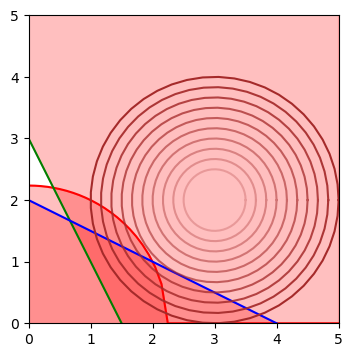

In [65]:
import matplotlib.pyplot as plt
import numpy as np

def g0u(x):
    res = np.zeros(len(x))
    for i in range(len(x)):
        if x[i] >= 0 and x[i] <= 5**.5:
            np.put(res, i, (-x[i]**2+5)**.5)
    return res

def g1(x):
    return 3-2*x

def g2(x):
    return (4-x)/2

x = np.linspace(0,5)
plt.figure(figsize=(4,4))
plt.xlim(0,5)
plt.ylim(0,5)
plt.plot(x, g0u(x), color="red")
plt.plot(x, g1(x), color="green")
plt.plot(x, g2(x), color="blue")
plt.fill_between(x,0,g0u(x), color="red", alpha=0.25)
plt.fill_between(x,10,g1(x), color="red", alpha=0.25)
plt.fill_between(x,0,g2(x), color="red", alpha=0.25)

for i in range(10):
    ang = np.linspace(0,2*np.pi)
    xc = 3+(2-i/6)*np.cos(ang)
    yc = 2+(2-i/6)*np.sin(ang)
    plt.plot(xc, yc, color="brown", alpha=(1-(i/12)))
plt.show()

#### Ejercicio 3.

Considere el siguiente problema de optimización no lineal P.

$$ máx f(x,y) = x $$

$$ (x-1)^2 + y^2 \ge 1 $$

$$ (x-2)^2 + y^2 \le 4$$

$$ (x-3)^2 + y^2 \ge 1 $$ 

- Grafique el area de decisíón.
- Encuentre todos los puntos estacionarios y caractericelos.
- Programe el problema en scipy.optimize.

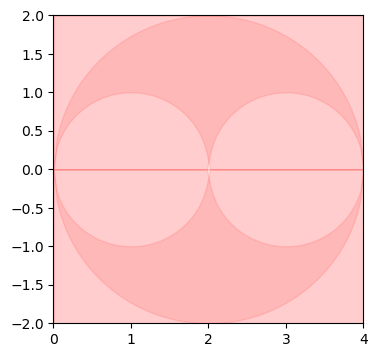

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def g0u(x):
    res = np.zeros(len(x))
    for i in range(len(x)):
        if x[i] > 0 and x[i] < 2:
            np.put(res, i, (1-(x[i]-1)**2)**.5)
    return res
def g0d(x):
    res = np.zeros(len(x))
    for i in range(len(x)):
        if x[i] > 0 and x[i] < 2:
            np.put(res, i, -(1-(x[i]-1)**2)**.5)
    return res
    
def g1u(x):
    res = np.zeros(len(x))
    for i in range(len(x)):
        if x[i] > 0 and x[i] < 4:
            np.put(res, i, (4-(x[i]-2)**2)**.5)
    return res
def g1d(x):
    res = np.zeros(len(x))
    for i in range(len(x)):
        if x[i] > 0 and x[i] < 4:
            np.put(res, i, -(4-(x[i]-2)**2)**.5)
    return res

def g2u(x):
    res = np.zeros(len(x))
    for i in range(len(x)):
        if x[i] > 2 and x[i] < 4:
            np.put(res, i, (1-(x[i]-3)**2)**.5)
    return res
def g2d(x):
    res = np.zeros(len(x))
    for i in range(len(x)):
        if x[i] > 2 and x[i] < 4:
            np.put(res, i, -(1-(x[i]-3)**2)**.5)
    return res

x = np.linspace(0, 4,100)
plt.figure(figsize=(4,4))
plt.ylim(-2,2)
plt.xlim(0,4)
plt.fill_between(x, 2, g0u(x), color="red", alpha=0.1)
plt.fill_between(x, -2, g0d(x), color="red", alpha=0.1)
plt.fill_between(x, 0, g1u(x), color="red", alpha=0.1)
plt.fill_between(x, 0, g1d(x), color="red", alpha=0.1)
plt.fill_between(x, 2, g2u(x), color="red", alpha=0.1)
plt.fill_between(x, -2, g2d(x), color="red", alpha=0.1)
plt.show()

Recordar que se debe normalizar el problema

In [33]:
from scipy.optimize import minimize
import numpy as np

def objetivo(x):
    return -x[0]

def r0(x):
    return 1 - (x[0]-1)**2 - x[1]**2
def r1(x):
    return (x[0]-2)**2 + x[1]**2 - 4
def r2(x):
    return 1 - (x[0]-3)**2 - x[1]**2

# si hay mas restricciones se agregan a la lista
rest_list = [{'type': 'ineq', 'fun': r0}, {'type': 'ineq', 'fun': r1}, {'type': 'ineq', 'fun': r2}]

solucion_inicial = np.array([0, 0])

# Minimize the function using the Nelder-Mead method
result = minimize(objetivo, solucion_inicial, method='SLSQP', constraints=rest_list)

# Print the result
print(result)

 message: Positive directional derivative for linesearch
 success: False
  status: 8
     fun: -9.629585848877324e-15
       x: [ 9.630e-15  0.000e+00]
     nit: 7
     jac: [-1.000e+00  0.000e+00]
    nfev: 29
    njev: 3
